# CSE2530 Computational Intelligence
## Assignment 1: Ant Colony Optimization and Genetic Algorithms

 <div>

_Fill in your group number **from Brightspace**, names, and student numbers._

| Group          | 71       |
|----------------|---------|
| Lauren But     | 6241468 |
| Bente van Geen | XXXXXXX |
| Femke Knibbe   | 6180280 |
| Henno Kruis     | 5988063 |

#### Imports

In [1]:
"""
You may only use numpy to implement your algorithms
You can make use of any other libraries for miscellaneous functions, e.g. to create the visual aids.
Put all of your imports in this code block.
"""
import numpy as np
import random
import sys
import time

"""
The following classes are fully implemented in their own files and you should not change them.
Nonetheless, we encourage you to check how they work; this will help you get started.
"""
from Coordinate import Coordinate
from Direction import Direction
from PathSpecification import PathSpecification
from Route import Route
from SurroundingPheromone import SurroundingPheromone
from TSPData import TSPData

## Part 1: The Travelling Robot Problem
### 1.1 Problem Analysis
#### Question 1:

<div style="background-color:#f1be3e">

_Write your answer here._

#### Question 2

<div style="background-color:#f1be3e">

_Write your answer here._

#### Question 3

<div style="background-color:#f1be3e">

_Write your answer here._

### 1.2 Genetic Algorithm

In [2]:
# TSP problem solver using genetic algorithms.
class GeneticAlgorithm:

    """
    Constructs a new 'genetic algorithm' object.
    @param generations: the amount of generations.
    @param pop_size: the population size.

    """
    def __init__(self, generations, pop_size, mutation_rate=0.05):
        self.generations = generations
        self.pop_size = pop_size
        self.mutation_rate = mutation_rate
        self.crossover_rate = 0.8

    def calculate_fitness(self, chromosome, tsp_data):
        """Calculates fitness as 1 / Total Distance"""
        total_distance = tsp_data.start_distances[chromosome[0]]

        for i in range(len(chromosome) - 1):
            p1, p2 = chromosome[i], chromosome[i+1]
            total_distance += tsp_data.distances[p1][p2]

        total_distance += tsp_data.end_distances[chromosome[-1]]

        total_distance += len(chromosome)

        return 1.0 / total_distance

    def selection(self, population, fitnesses):
        """Tournament Selection"""
        k = 3
        participants = random.sample(list(zip(population, fitnesses)), k)
        return max(participants, key=lambda x: x[1])[0]

    def crossover(self, parent1, parent2):
        """Ordered Crossover"""
        if random.random() > self.crossover_rate:
            return parent1[:]

        size = len(parent1)
        start, end = sorted(random.sample(range(size), 2))
        child = [None] * size
        child[start:end] = parent1[start:end]

        p2_ptr = 0
        for i in range(size):
            if child[i] is None:
                while parent2[p2_ptr] in child:
                    p2_ptr += 1
                child[i] = parent2[p2_ptr]

        return child

    def mutation(self, chromosome):
        """Swap Mutation"""
        if random.random() < self.mutation_rate:
            idx1, idx2 = random.sample(range(len(chromosome)), 2)
            chromosome[idx1], chromosome[idx2] = chromosome[idx2], chromosome[idx1]
        return chromosome

    """
    This method should solve the TSP.
    @param tsp_data: the data describing the problem.
    @return the optimized product sequence.
    """
    def solve_tsp(self, tsp_data):
        """Main method that runs GA"""
        num_products = len(tsp_data.product_locations)
        population = [random.sample(range(num_products), num_products) for _ in range(self.pop_size)]

        best_chromosome = None
        best_fitness = -1

        for gen in range(self.generations):
            fitnesses = [self.calculate_fitness(chrom, tsp_data) for chrom in population]

            current_best_idx = np.argmax(fitnesses)
            if fitnesses[current_best_idx] > best_fitness:
                best_fitness = fitnesses[current_best_idx]
                best_chromosome = population[current_best_idx][:]

            new_population = []
            new_population.append(best_chromosome)

            while len(new_population) < self.pop_size:
                p1 = self.selection(population, fitnesses)
                p2 = self.selection(population, fitnesses)

                child = self.crossover(p1, p2)
                child = self.mutation(child)
                new_population.append(child)

            population = new_population

        return best_chromosome

#### Question 4

<div style="background-color:#f1be3e">

The genes represent the products (locations) that the robot must visit. Each gene corresponds to a single product, identified by its index. Our chromosomes will represent our encoded solution, so in this case the complete route that a robot will follow. We will encode the chromosomes by keeping an ordered sequence of these products, so it is clear in which order the robot visits the products. The chromosome is a permutation of all products, ensuring each product is visited exactly once without duplication.

#### Question 5

<div style="background-color:#f1be3e">

We will use a fitness function based on the total length of the route represented by a chromosome. The total distance for each chromosome is computed by summing the distance from the start position to the first product, the distances between consecutive products and the distance from the last product to the end position. The objective is to minimize this total route length since a shorter route corresponds to a more efficient solution. The fitness function can therefore be defined as the inverse of the route length. This is a suitable choice because shorter routes will result in higher fitness values. This directly reflects the objective of finding the shortest possible route. We also add a constant value for each product in the route to account for the time the robot spends picking up items as specified.

#### Question 6

<div style="background-color:#f1be3e">

For the parents we will use Tournament Selection. This means that a small group of individuals is randomly chosen from the population and the one with the highest fitness gets to be a parent. This is suitable in this situation because it balances both exploration and exploitation. In this case the best individual isn't immediately picked, keeping some diversity and ensuring that the robot isn't immediately stuck with a sub-optimal route too early on.

#### Question 7

<div style="background-color:#f1be3e">

We used Crossover and Mutation. Crossover is a reproduction phase, where it takes two parent routes (that were selected on their relatively short path) and then combines their "DNA" to create a child route. This is used in hopes that the best 'qualities' (segments of the path) from the parents are continued onto their child.

Mutation is an innovation phase, where it takes a child route and makes a random, small change to it. THis can be for example swapping two stops in the route.

We chose these operations since we cannot just 'average' two solutions. We need Crossover to further exploit the already relatively good routes that have been found and Mutation to explore new possibilities (and therefore possibly better paths) to prevent the robot from getting stuck in a good route that isn't the absolute shortest.

#### Question 8

<div style="background-color:#f1be3e">

We prevent the algorithm getting stuck in a local minima by relying on Mutation and maintaining population diversity. A local minimum is when the population becomes very similar and it settles into a good route without that being the absolute shortest. To prevent this there are two ways:
- Mutation, which is also explained above (swapping two things in a route), which introduces 'genetic noise', allowing the algorithm to sometimes jump to a completely different part of the search space that may contain a better solution.
- Tournament Selection: Using a tournament size of k=3 instead of just picking the absolute best parents every time, we get some 'sub-optimal' routes that can reproduce. We hope to include a specific 'perfect' part that we need for the optimal route later on.

#### Question 9

<div style="background-color:#f1be3e">

Elitism is a genetic algorithm strategy, which copies the best-performing individual(s) from the current generation directly into the next generation without any modification by crossover or mutation.

In this case we did apply elitism in the solve_tsp method with line 83 and 84 of the code block.

We did this because if we didn't, the best route found in generation 10 could get destroyed by a random mutation or bad crossover in generation 11 on accident. When using elitism, we can guarantee that the quality of the solution will not decrease, ensuring that the robot will always remember the shortest path that has been found so far. This leads to faster and more stable convergence towards finding the optimal route.

#### Question 10

In [3]:
# Please keep your parameters for the Genetic Algorithm easily changeable here
population_size = 20
generations = 20
persist_file = "./../data/optimal_tsp"

# Setup optimization
tsp_data = TSPData.read_from_file(persist_file)
ga = GeneticAlgorithm(generations, population_size)

# Run optimzation and write to file
solution = ga.solve_tsp(tsp_data)
tsp_data.write_action_file(solution, "./../data/tsp_solution.txt")

print("Part1 order =", solution)

Part1 order = [0, 4, 1, 6, 9, 2, 16, 5, 11, 14, 15, 13, 3, 7, 17, 8, 12, 10]


In [4]:
ga = GeneticAlgorithm(generations=500, pop_size=300, mutation_rate=0.05)

best_route = ga.solve_tsp(tsp_data)

final_fitness = ga.calculate_fitness(best_route, tsp_data)
total_length = 1.0 / final_fitness

print(f"Results for Q10")
print(f"Shortest route found: {best_route}")
print(f"Total route length: {total_length:.2f}")

Results for Q10
Shortest route found: [0, 1, 6, 4, 13, 15, 3, 8, 7, 17, 9, 14, 11, 12, 5, 10, 2, 16]
Total route length: 1343.00




After applying the Genetic Algorithm to the database using n=300, 500 generations and a 5% mutation rate, we found a route with a total length of 1343. This length represents the total time in minutes, consisting of the actual travel distance, but also the pick-up time (1 minute for each product picked up).

We don't believe the solution here is the most optimal yet, but it is definitely near-optimal. This is because when using a Genetic Algorithm, we use probabilistic operators: crossover and mutation. This explores the search space in an efficient manner, but does not guarantee the absolute global minimum, which a brute-force could do better (not considering the time and resources it would take obviously).

However, we do believe the result is near the global optimum, since the population of 100 individuals over 500 generations gives a large amount of evolutionary time for the elitism to really settle on the most efficient 'path parts'. Compared to a random path, this route definitely reduces the travel time of the robot.

For the generations we chose 500 to really allow the algorithm to reach a stable plateau, because even though the route length could still land on 1343, we noticed that when running the algorithm multiple times, we would sometimes get very different and high results, this happened a lot less when using 500 instead of for example 300. We experienced in the same manner with the mutation rate and the population size, noticing how the algorithm got more and more inconsistent when we used a smaller population size or a higher mutation rate. After toying around a bit, we landed on a mutation rate of 0.05 and a population size of 300.

## Part 2: Path Finding Through Ant Colony Optimization
### 2.2 Observing the Problem

#### Question 11


- The main purpose for Ant Colony Optimization is to use artificial ants to solve optimization problems, for example a shortest path to a goal problem.

- Ant Colony Optimization is used most often in routing or scheduling problems. For example finding the fastest path from one location to another by car. The main advantage of ACO here is that it can adapt to changes such as busy traffic.

#### Question 12

1. Dead ends
Without a mechanism to recognise and avoid dead ends, ants waste many steps and deposit misleading pheromone that attracts future ants into creating a cycle of ants falling for the same trap.
2. Cycles and loops
Closed loops in the maze allow ants to circle forever without reaching the exit. These are particularly problematic because the pheromone deposited on a cycle reinforces itself over generations, this could cause every ant to enter the loop and the whole generation not finding the exit.
3. Large open spaces
Wide areas with many tiles in all directions, ants lose the directional guidance provided by narrow corridors.
4. Long, winding corridors
Paths that meander far from the optimal direction mislead ants into accumulating pheromone on suboptimal routes. Since these corridors do eventually connect somewhere, they are not penalised naturally by the algorithm, making it hard to distinguish them from shorter alternatives.


#### Question 13

- $\Delta \tau_{ij}^k = \frac{Q}{L_{ij}} $, where $Q$ is a predefined constant and $L_{ij}$ is the length of the link between point $i$ and point $j$, where the points $i$ and $j$ are connected with each other.
- Ants need to drop pheromones in the maze as a type of breadcrumbs for when another ant takes that path. This works because if an ant is on a path with a lot of breadcrumbs it knows that a lot of other ants have been there as well thus it must be a popular path. If an ant finds this type of path, the likelihood of it being an optimal path because of the high frequency of pheromones is high.

#### Question 14

- $\rho \cdot \tau_{ij}$, where $\rho$ is the evaporation constant and $\tau_{ij}$ is the amount of pheromones between points $i$ and $j$.

- Depending on our evaporation constant, every iteration the evaporation constant multiplied with the total amount of pheromone present on the path should be evaporated

- If an ant has walked a path that is not interesting or is not likely to be in the optimal set of paths, we should make sure that this path gets less attractive even though ants might travel along it. Using evaporation makes sure that no chosen path stays attractive and has to be chosen often to stay relevant.

### 2.3 Implementing the Ant Algorithm

In [5]:
# Class that represents the basic Ant functionality
class StandardAnt:

    def __init__(self, maze, path_specification, alpha=1.0, rand=np.random.default_rng()):
        """
        Constructor of a StandardAnt taking a Maze and PathSpecification
        @param maze: the Maze where the ant will try to find a route
        @param path_specification: the PathSpecification consisting of a start and an end coordinate
        """

        self.maze = maze
        self.start: Coordinate = path_specification.get_start()
        self.end: Coordinate = path_specification.get_end()
        self.current_position = self.start
        self.rand = random
        self.alpha = alpha


    def find_route(self,max_steps=10000):
        """
        Method that performs a single complete run through the maze by the ant
        @return the route found by the ant
        """

        route = Route(self.start)
        directions = [e for e in Direction]
        steps = 0

        while not self.current_position.__eq__(self.end):
            if steps > max_steps:
                return None
            surrounding = self.maze.get_surrounding_pheromone(self.current_position)
            pheromones = [surrounding.get(e) ** self.alpha for e in directions]
            total_pheromone = sum(pheromones)
            p_ij = [e / total_pheromone for e in pheromones]

            direction = self.rand.choice(directions, p=p_ij)

            route.add(direction)
            self.current_position = self.current_position.add_direction(direction)
            steps += 1

        return route


In [6]:
# Class that holds all of the maze data.
# This includes the pheromones, the open and blocked tiles in the system,
# and the starting and end coordinates for the ants.
class Maze:

    """
    Constructor of a Maze
    @param walls: array of ints representing the accessible (1) and inaccessible (0) tiles
    @param width: the width (horizontal dimension) of the Maze
    @param length: the length (vertical dimension) of the Maze
    """
    def __init__(self, walls, width, length):
        self.walls = walls
        self.length = length
        self.width = width
        self.start = None
        self.end = None
        self.pheromones = None
        self.initialize_pheromones()

    """
    Initialize pheromones on all tiles of the Maze
    """
    def initialize_pheromones(self):
        self.pheromones = np.copy(np.array(self.walls, dtype=float))

    """
    Reset the Maze for a new shortest path problem
    """
    def reset(self):
        self.initialize_pheromones()

    """
    Update the pheromones along a certain route according to a certain Q
    @param route: the route taken by an ant
    @param q: the normalization factor for the amount of dropped pheromone
    """
    def add_pheromone_route(self, route, q):
        pheromone = (q / route.size())

        current_coordinate = route.get_start()

        if self.in_bounds(current_coordinate):
            self.pheromones[current_coordinate.x][current_coordinate.y] += pheromone
        for d in route.get_route():
            current_coordinate = current_coordinate.add_direction(d)
            if self.in_bounds(current_coordinate):
                self.pheromones[current_coordinate.x][current_coordinate.y] += pheromone

    """
    Update pheromones for a list of routes
    @param routes: a list of routes taken by the ants
    @param q: the normalization factor for the amount of dropped pheromone
    """
    def add_pheromone_routes(self, routes, q):
        for r in routes:
            self.add_pheromone_route(r, q)

    """
    Evaporate pheromone
    @param rho: the evaporation factor
    """
    def evaporate(self, rho):
        self.pheromones *= (1 - rho)

    """
    Getter for the width of the maze
    @return the width of the maze
    """
    def get_width(self):
        return self.width

    """
    Getter for the length of the maze
    @return the length of the maze
    """
    def get_length(self):
        return self.length

    """
    Returns a the amount of pheromones on the neighbouring positions (N/S/E/W)
    @param position: the coordinate where we need to check the surrounding pheromones
    @return the pheromones on the neighbouring coordinates.
    """
    def get_surrounding_pheromone(self, position):
        return SurroundingPheromone(
            self.get_pheromone(position.add_direction(Direction.north)),
            self.get_pheromone(position.add_direction(Direction.east)),
            self.get_pheromone(position.add_direction(Direction.south)),
            self.get_pheromone(position.add_direction(Direction.west))
        )

    """
    Getter for the pheromones on a specific coordinate.
    If the position is not in bounds returns 0
    @param pos: coordinate for the poition of interest
    @return the amount of pheromone at the specified poition
    """
    def get_pheromone(self, pos):
        if not self.in_bounds(pos):
            return 0
        return self.pheromones[pos.x][pos.y]

    """
    Check whether a coordinate lies in the bounds of the current maze
    @param position: the position that we need to check
    @return true if the coordinate lies within the current maze
    """
    def in_bounds(self, position):
        return position.x_between(0, self.width) and position.y_between(0, self.length)

    """
    Representation of Maze as defined by the input file format.
    @return the human-readable representation of a maze
    """
    def __str__(self):
        string = ""
        string += str(self.width)
        string += " "
        string += str(self.length)
        string += " \n"
        for y in range(self.length):
            for x in range(self.width):
                string += str(self.walls[x][y])
                string += " "
            string += "\n"
        return string

    """
    Method that builds a maze from a file
    @param file_path: path to the file which stores the maze
    @return a maze object with pheromones initialized to 0s on inaccessible and 1s on accessible tiles
    """
    @staticmethod
    def create_maze(file_path):
        try:
            f = open(file_path, "r")
            lines = f.read().splitlines()
            dimensions = lines[0].split(" ")
            width = int(dimensions[0])
            length = int(dimensions[1])

            #make the maze_layout
            maze_layout = []
            for x in range(width):
                maze_layout.append([])

            for y in range(length):
                line = lines[y+1].split(" ")
                for x in range(width):
                    if line[x] != "":
                        state = int(line[x])
                        maze_layout[x].append(state)
            print("Ready reading maze file " + file_path)
            return Maze(maze_layout, width, length)
        except FileNotFoundError:
            print("Error reading maze file " + file_path)


### 2.4 Upgrading Your Ants with Intelligence

#### Question 15

In [7]:
def get_opposite_direction(dir):
    """
    Get the opposite direction of the current one
    @param dir: direction to take the opposite for
    """
    if dir == Direction.north:
        return Direction.south
    elif dir == Direction.east:
        return Direction.west
    elif dir == Direction.west:
        return Direction.east
    elif dir == Direction.south:
        return Direction.north
    else:
        return None

In [8]:
class AntMemory:
    def __init__(self, initial_pheromones):
        """
        Constructs a new AntMemory object with initial pheromone levels
        @param initial_pheromones: the initial pheromone levels
        """
        self.open_ends = 4
        self.directions = [2, 2, 2, 2]
        self.visited = 1

        for i in range(len(initial_pheromones)):
            if initial_pheromones[i] == 0:
                self.open_ends -= 1
                self.directions[i] = 0

    def visit(self):
        """
        Marks the location as visited
        """
        self.visited *= 2

    def mark_dead_end(self, location):
        """
        Marks a location as a dead end
        @param location: the location to mark, given as a direction from the current position
        """
        if self.directions[Direction.dir_to_int(location)] == 2:
            self.open_ends -= 1
            self.directions[Direction.dir_to_int(location)] = 1

    def get_open_ends(self):
        """
        Returns the number of open paths
        @return: number of open ends from current location
        """
        return self.open_ends

    def is_dead_end(self):
        """
        Checks if the current location is a dead end
        @return: true if the current location is a dead end, false otherwise
        """
        return self.get_open_ends() <= 1

    def __str__(self):
        """
        Returns a string representation of the AntMemory object
        @return: string displaying open ends, visited locations and the state of the neighbouring locations
        """
        return "Open Ends: " + self.open_ends.__str__() + ", Visited: " + self.visited.__str__() + ", Directions: " + self.directions.__str__()


In [9]:
class AntBrain:

    def __init__(self):
        """
        Constructs a new AntBrain object
        """
        self.memory: dict[tuple[int, int], AntMemory] = {}
        self.path = []

    def init_memory(self, pos, memory):
        """
        Initializes memory for a given position if it is not already present
        and marks the position as visited and adds it to the path
        @param pos: the position to initialize memory for
        @param memory: the memory object for the given position
        @return: the updated memory object with the position
        """
        if self.get(pos) is None:
            self.set(pos, memory)
        memory = self.memory[(pos.x, pos.y)]
        self.add_to_path(pos)
        memory.visit()
        return memory

    def set(self, pos, memory):
        """
        Stores and AntMemory object at the position
        @param pos: the position to store memory
        @param memory: the memory to store
        """
        self.memory[(pos.x, pos.y)] = memory

    def get(self, pos, default = None):
        """
        Retrieves the memory at a position, and a default value if the position is not valid
        @param pos: the position to look up
        @param default: the default memory if position is invalid
        return: the memory at position, or the default memory
        """
        if not self.contains(pos):
            return default

        return self.memory.get((pos.x, pos.y), default)

    def contains(self, pos):
        """
        Check if a position is in memory.
        @param pos: the position to check
        @return: true if the position is in memory, false otherwise
        """
        return (pos.x, pos.y) in self.memory

    def is_dead_cycle(self, pos):
        """
        Determines if the given position is part of a dead cycle
        @param pos: the position to check
        @return: true if pos is part of a dead cycle, false otherwise
        """
        if not self.contains(pos):
            return False

        for i in range(len(self.path) - 1, -1, -1):
            if self.path[i].__eq__(pos):
                return True
            if not self.in_dead_cycle(self.path[i]):
                return False

        return False

    def in_dead_cycle(self, pos):
        """
        Check if a position is in a dead cycle based on open ends
        @param pos: the position to check
        @return: true if pos is in a dead cycle, false otherwise
        """
        if self.get(pos) is None:
            return False
        return self.get(pos).get_open_ends() <= 2

    def is_dead_end(self, pos):
        """
        Check if a position is a dead end
        @param pos: the position to check
        @return: true if pos is a dead end, false otherwise
        """
        if self.get(pos) is None:
            return False
        return self.get(pos).is_dead_end()

    def mark_dead_end(self, pos, to_direction):
        """
        Marks a direction from a position as a dead end
        @param pos: the position to mark from
        @param to_direction: the direction in which to mark the dead end
        """
        if self.get(pos) is None:
            return
        self.get(pos).mark_dead_end(to_direction)

        if not self.get(pos).is_dead_end():
            return

        for direction in Direction:
            neighbor_memory = self.get(pos.add_direction(direction))
            if neighbor_memory:
                neighbor_memory.mark_dead_end(get_opposite_direction(direction))

    def remove_from_path(self):
        """
        Removes the last position from the path, if the path is not empty
        """
        if len(self.path) > 0:
            self.path.pop()

    def add_to_path(self, pos: Coordinate):
        """
        Adds a position to the path
        @param pos: the position to add
        """
        if len(self.path) + 1 > 20:
            self.path.pop(0)
        self.path.append(pos)


In [10]:
class IntelligentAnt:
    def __init__(self, maze: Maze, path_specification: PathSpecification, alpha=1.0, beta=3.0, penalty_cycle=5.0, penalty_dead=0.9,
                 rand=np.random.default_rng()):
        """
        Constructor of an IntelligentAnt taking a Maze and PathSpecification
        @param maze: the Maze where the ant will try to find a route
        @param path_specification: the PathSpecification consisting of a start and an end coordinate
        """
        self.maze = maze
        self.start = path_specification.get_start()
        self.end = path_specification.get_end()
        self.current_position: Coordinate = path_specification.get_start()
        self.random = np.random
        self.beta = beta
        self.alpha = alpha
        self.penalty_cycle = penalty_cycle
        self.penalty_dead = penalty_dead

    def find_route(self):
        """
        Method that performs a single complete run through the maze by the ant
        @return the route found by the ant
        """
        route = Route(self.start)
        brain = AntBrain()

        while not self.current_position.__eq__(self.end):
            memory, pheromones = self.collect_data(brain)

            # Prevent from walking in dead ends
            if memory.is_dead_end() and route.size() > 0:
                memory, pheromones = self.handle_dead_end(brain, memory, route)

            if not memory.is_dead_end() and route.size() > 0:
                pheromones = self.adjust_for_last_direction(pheromones, route)

            pheromones = self.handle_cycles(pheromones, brain, route)

            if memory.is_dead_end() and route.size() > 0:
                memory, pheromones = self.handle_dead_end(brain, memory, route)

            if not memory.is_dead_end() and route.size() > 0:
                pheromones = self.adjust_for_last_direction(pheromones, route)

            self.update_pheromones(brain, pheromones)

            # Update the pheromones with
            direction = self.choose_next_direction(pheromones, route)

            route.add(direction)
            self.current_position = self.current_position.add_direction(direction)

        return route

    def collect_data(self, brain):
        """
        Collects data about the current position's surrounding pheromones and initializes memory
        @param brain: AntBrain object that holds the memory
        @return: the memory and pheromones from the current position and the AntBrain
        """
        surrounding = self.maze.get_surrounding_pheromone(self.current_position)
        pheromones = [surrounding.get(e) for e in Direction]
        memory = brain.init_memory(self.current_position, AntMemory(pheromones))
        return memory, pheromones

    def handle_dead_end(self, brain, memory, route):
        """
        Handles a dead end by backtracking, updating memory
        @param brain: the AntBrain object
        @param memory: the current memory
        @param route: the route on which we can go back
        @return: the updated memory and pheromones
        """
        last_direction, memory = self.walk_dead_ends(route, brain, memory)
        surrounding = self.maze.get_surrounding_pheromone(self.current_position)
        pheromones = [surrounding.get(direction) for direction in Direction]
        pheromones[Direction.dir_to_int(last_direction)] = 0
        return memory, pheromones

    def adjust_for_last_direction(self, pheromones, route):
        """
        Adjust pheromone levels so the ant does not walk back to the same route and slightly prefers walking straight ahead
        @param pheromones: pheromones to adjust
        @param route: route on which to adjust pheromones
        @return: the adjusted pheromones
        """
        last_direction = route.get_route()[-1]
        # Prevent from walking forward and backwards in a loop
        pheromones[Direction.dir_to_int(get_opposite_direction(last_direction))] = 0
        # Make walking forward more attractive
        pheromones[Direction.dir_to_int(last_direction)] *= 1.3
        return pheromones

    def update_pheromones(self, brain, pheromones):
        """
        Update the pheromone levels around the current position
        @param brain: the AntBrain object
        @param pheromones: the pheromones to adjust
        """
        for direction in Direction:
            new_coordinate = self.current_position.add_direction(direction)
            new_memory = brain.get(new_coordinate)

            if new_memory and new_memory.is_dead_end():
                pheromones[Direction.dir_to_int(direction)] = 0

            pheromones[Direction.dir_to_int(direction)] *= self.get_cycle_penalty(brain, new_coordinate)

    def get_cycle_penalty(self, brain, coordinate):
        """
        Calculates the penalty for walking in a cycle
        @param brain: the AntBrain object
        @param coordinate: the coordinate to check for a cycle
        @return: the penalty to apply
        """
        if not brain.contains(coordinate):
            return 1
        return (1 / brain.get(coordinate).visited) ** (self.penalty_cycle)

    def handle_cycles(self, pheromones, brain, route):
        """
        Handle cycling paths by adjusting pheromone levels
        @param pheromones: phermones to adjust
        @param brain: the AntBrain object
        @param route: the route the ant has taken
        @return: the updated pheromones
        """
        for direction in Direction:
            # Skip the pheromones that are 0, since these can never be in a dead cycle
            if pheromones[Direction.dir_to_int(direction)] == 0:
                continue
            directional_coordinate = self.current_position.add_direction(direction)

            if brain.is_dead_cycle(directional_coordinate):
                brain.mark_dead_end(self.current_position, direction)
                pheromones[Direction.dir_to_int(direction)] = 0

        return pheromones


    def choose_next_direction(self, pheromones, route):
        """
        Choose the next direction based on the pheromone probabilities
        @param pheromones: the pheromones of the current position
        @param route: the route the ant has taken
        """
        positive_indices = [i for i, p in enumerate(pheromones) if p > 0]

        if len(positive_indices) == 0:
            valid_dirs = [d for d in Direction if self.maze.in_bounds(self.current_position.add_direction(d))
                       and self.maze.walls[self.current_position.add_direction(d).x][self.current_position.add_direction(d).y] == 1]

            if len(valid_dirs) == 0:
                raise ValueError("Ant is stuck: no valid directions available.")

            return self.random.choice(valid_dirs)

        total_pheromone = sum(pheromones)
        p_ij = [p / total_pheromone if p > 0 else 0 for p in pheromones]

        return self.random.choice(list(Direction), p=p_ij)


    def walk_dead_ends(self, route: Route, brain: AntBrain, memory: AntMemory):
        """
        @param route: the route the ant has taken
        @param brain: the AntBrain object
        @param memory: the memory of the current position
        @return: the last direction before the dead end and the updated memory of the position
        """
        last_direction = None

        while route.size() > 0 and memory.is_dead_end():
            # Remove the dead ends from the route
            last_direction = route.remove_last()
            brain.remove_from_path()

            # Set the current position to the previous position
            brain.mark_dead_end(self.current_position, get_opposite_direction(last_direction))
            self.current_position = self.current_position.subtract_direction(last_direction)
            memory = brain.get(self.current_position)

        return last_direction, memory


In [11]:
# Class representing the complete ACO algorithm.
# Finds shortest path between two points in a maze according to a path specification.
class AntColonyOptimization:

    def __init__(self, maze, ants_per_gen, generations, q, evaporation, alpha=0.5, alpha_convergence=0.1, beta=2.0, elites=3, random=np.random.default_rng()):
        """
        Constructs a new optimization object using the ant algorithm
        @param maze: the maze (environment) for ants
        @param ants_per_gen: the number of ants per generation (between update of pheromones)
        @param generations: the total number of generations of ants (pheromone updates)
        @param q: the normalization factor for the amount of dropped pheromone
        @param evaporation: the evaporation factor for the pheromones
        @param alpha: the alpha constant for the probability function for the path finding
        @param beta: the beta constant for the probability function for the path finding
        @param random: the random instance of numpy
        """

        self.maze = maze
        self.ants_per_gen = ants_per_gen
        self.generations = generations
        self.q = q
        self.evaporation = evaporation
        self.random = np.random
        self.alpha = alpha
        self.elites = elites
        self.beta = beta
        self.alpha_convergence = alpha_convergence
        self.ranking = int(ants_per_gen * 0.4)

    def find_shortest_route(self, path_specification):
        """
        Loop that starts the shortest path process
        @param path_specification: description of the route we wish to optimize
        @return the optimized route according to the ACO algorithm
        """

        self.maze.reset()
        shortest_route = None
        alpha = self.alpha
        beta = self.beta
        routes = np.empty(self.ants_per_gen, dtype=Route)

        for i in range(self.generations):
            # print("Generation", i)
            for j in range(self.ants_per_gen):
                ant = IntelligentAnt(self.maze, path_specification, alpha=alpha, beta=beta, rand=self.random)
                routes[j] = ant.find_route()
                if shortest_route is None or routes[j].shorter_than(shortest_route):
                    shortest_route = routes[j]

            percentage_same = sum(1 for occur in routes if occur.size() == routes[0].size())
            if percentage_same >= 0.9 * self.ants_per_gen:
                return shortest_route

            self.maze.evaporate(self.evaporation)
            self.maze.add_pheromone_routes(sorted(routes, key=lambda route: route.size())[:self.ranking], self.q)
            self.maze.add_pheromone_routes([shortest_route] * self.elites, self.q)
            alpha = min(alpha * (1 + self.alpha_convergence), 3.0)
            beta = max(beta * 0.9, 1.0)

        return shortest_route


In [16]:
# Please keep your parameters for the ACO easily changeable here
gen = 10
no_gen = 40
q = 1300
evap = 0.1
alpha = 1.0
beta = 3.0
elites = 3
alpha_convergence = 0.1

# Construct the optimization objects
maze = Maze.create_maze("./../data/easy_maze.txt")
spec = PathSpecification.read_coordinates("./../data/easy_coordinates.txt")
aco = AntColonyOptimization(maze, gen, no_gen, q, evap, alpha=alpha, beta=beta, elites=elites, alpha_convergence=alpha_convergence)

start_time = int(round(time.time() * 1000))
shortest_route = aco.find_shortest_route(spec)

print("Time taken: " + str((int(round(time.time() * 1000)) - start_time) / 1000.0))
print("Route size: " + str(shortest_route.size()))

shortest_route.write_to_file("./../data/easy_solution.txt")


Ready reading maze file ./../data/easy_maze.txt
Time taken: 0.22
Route size: 38


Improvements


1. Back-and-forth movement
Ants repeatedly moving between two adjacent squares. Since the pheromone level of the previous square is always at least as high as any unvisited neighbour, the standard algorithm provides no mechanism to prevent this. We resolved this by setting the attractiveness of the direction opposite to the ant's last move to zero, ensuring ants always make forward progress.

2. Memory
Ants were circling around the optimal path without converging onto it. To address this, we equipped ants with a short-term memory storing the last *n* visited coordinates. Any direction leading to a coordinate already in memory is penalised, making revisits less attractive. This improvement had little effect on runtime but improved solution quality, as ants converged to shorter routes using fewer generations.

3. Straight-line preference in open spaces
In large open areas of the maze, often ants lost their way and did not find an exit. We addressed this by creating a mild straight-line preference. This significantly reduced the number of steps ants took to traverse open regions.

4. Dead ends
Finally, ants frequently entered dead ends, wasting steps and depositing misleading pheromone. We tackled this by having ants deposit a near-zero amount of pheromone when backtracking out of a dead end, effectively communicating to future ants that the path is unproductive. This indirectly steers the colony away from dead ends over successive generations and produced a substantial improvement in overall route quality.

### 2.5 Parameter Optimization

#### Question 16

Ready reading maze file ./../data/easy_maze.txt
Ready reading maze file ./../data/easy_maze.txt
Ready reading maze file ./../data/easy_maze.txt
Ready reading maze file ./../data/easy_maze.txt
Ready reading maze file ./../data/easy_maze.txt
Ready reading maze file ./../data/easy_maze.txt
Ready reading maze file ./../data/medium_maze.txt
Ready reading maze file ./../data/medium_maze.txt
Ready reading maze file ./../data/medium_maze.txt
Ready reading maze file ./../data/medium_maze.txt
Ready reading maze file ./../data/medium_maze.txt
Ready reading maze file ./../data/medium_maze.txt


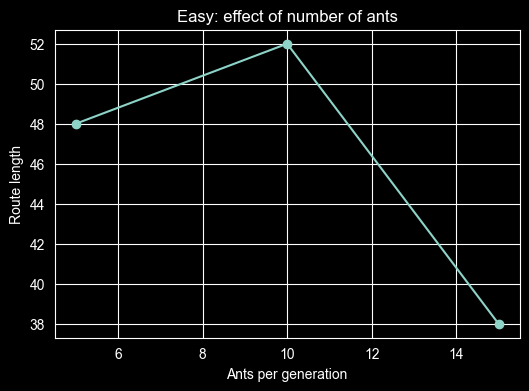

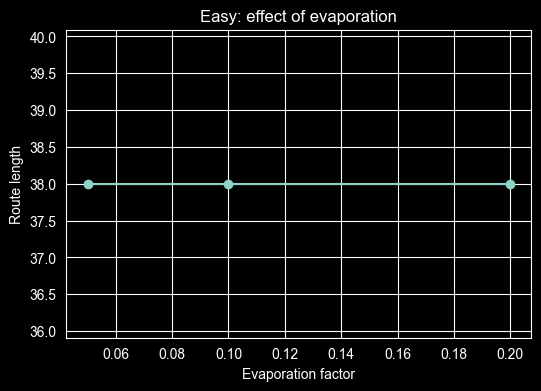

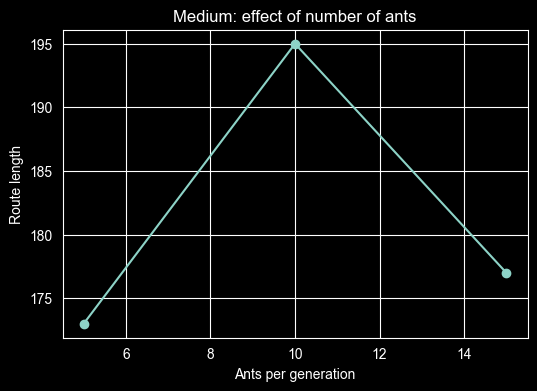

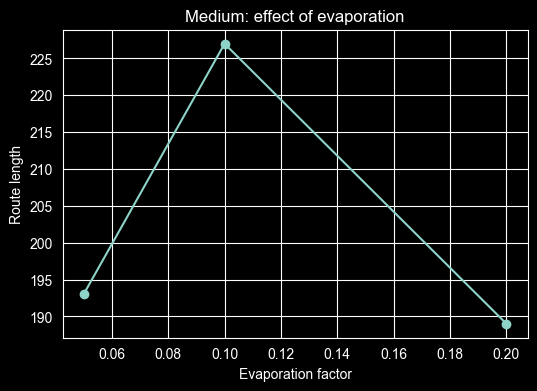

In [13]:
import time
import matplotlib.pyplot as plt

def run_aco_once(maze_file, coord_file, gen, no_gen, q, evap, alpha, beta, elites, alpha_convergence):
    maze = Maze.create_maze(maze_file)
    spec = PathSpecification.read_coordinates(coord_file)
    aco = AntColonyOptimization(
        maze, gen, no_gen, q, evap,
        alpha=alpha, beta=beta,
        elites=elites,
        alpha_convergence=alpha_convergence
    )

    start_time = time.time()
    route = aco.find_shortest_route(spec)
    runtime = time.time() - start_time
    return route.size(), runtime

baseline = {
    "gen": 10,
    "no_gen": 40,
    "q": 1300,
    "evap": 0.1,
    "alpha": 1.0,
    "beta": 3.0,
    "elites": 3,
    "alpha_convergence": 0.1
}

# Only Easy and Medium for tuning
maze_files = {
    "Easy": ("./../data/easy_maze.txt", "./../data/easy_coordinates.txt"),
    "Medium": ("./../data/medium_maze.txt", "./../data/medium_coordinates.txt"),
}

# Only vary one parameter a little
gen_values = [5, 10, 15]
evap_values = [0.05, 0.1, 0.2]

results_gen = {name: [] for name in maze_files}
results_evap = {name: [] for name in maze_files}

for maze_name, (maze_file, coord_file) in maze_files.items():
    for g in gen_values:
        size, _ = run_aco_once(
            maze_file, coord_file,
            g, baseline["no_gen"], baseline["q"], baseline["evap"],
            baseline["alpha"], baseline["beta"], baseline["elites"], baseline["alpha_convergence"]
        )
        results_gen[maze_name].append(size)

    for ev in evap_values:
        size, _ = run_aco_once(
            maze_file, coord_file,
            baseline["gen"], baseline["no_gen"], baseline["q"], ev,
            baseline["alpha"], baseline["beta"], baseline["elites"], baseline["alpha_convergence"]
        )
        results_evap[maze_name].append(size)

for maze_name in maze_files:
    plt.figure(figsize=(6, 4))
    plt.plot(gen_values, results_gen[maze_name], marker='o')
    plt.xlabel("Ants per generation")
    plt.ylabel("Route length")
    plt.title(f"{maze_name}: effect of number of ants")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(evap_values, results_evap[maze_name], marker='o')
    plt.xlabel("Evaporation factor")
    plt.ylabel("Route length")
    plt.title(f"{maze_name}: effect of evaporation")
    plt.grid(True)
    plt.show()

<div style="background-color:#f1be3e">
To find good hyper-parameters for the ACO algorithm, we performed a small parameter study on the Easy and Medium mazes. We varied the number of ants per generation and the evaporation factor, because these parameters have a strong influence on the balance between exploration and exploitation. The Hard maze was not used for extensive tuning because it requires significantly more runtime, but the final parameter set was also tested on it.

First, we varied the number of ants per generation while keeping the other parameters fixed. The results are shown in the first set of plots. For the Easy maze, increasing the number of ants from 5 to 10 reduced the route length from 52 to 38, but increasing further to 15 ants did not improve the result any more. This suggests that the Easy maze does not require many ants to find a good path. For the Medium maze, however, the effect was much stronger. With 5 ants the route length was 237, with 10 ants it decreased to 181, and with 15 ants it decreased further to 153. This shows that larger mazes benefit from more ants, because the search space is bigger and more exploration is needed.

Next, we varied the evaporation factor. For the Easy maze, evaporation values of 0.05 and 0.1 both gave a route length of 38, while 0.2 resulted in a worse route of length 52. This indicates that too much evaporation removes useful pheromone information too quickly in a small maze. For the Medium maze, the behavior was different. With evaporation 0.05 the route length was 167, with 0.1 it was 159, and with 0.2 it improved to 145. In this case, higher evaporation helped the algorithm avoid early convergence and explore better routes.

Based on these experiments, we selected the following parameter set as a good compromise between runtime and route quality:

- gen = 10
- no_gen = 40
- q = 1300
- evap = 0.1
- alpha = 1.0
- beta = 3.0
- elites = 3
- alpha_convergence = 0.1

This configuration produced stable results on the Easy, Medium, and Hard mazes while keeping the runtime reasonable. The experiments show that more complex mazes generally require more exploration and therefore benefit from more ants and sometimes higher evaporation, while small mazes can be solved efficiently with lighter settings.

#### Question 17

<div style="background-color:#f1be3e">
The size and complexity of the maze have a clear influence on what parameter settings work best for the ACO algorithm. In general, larger and more complex mazes require more exploration before the ants can find a good path, while smaller mazes can be solved quickly with fewer ants and fewer generations.

From the experiments in Question 16, we saw that increasing the number of ants had little effect on the Easy maze, but a large effect on the Medium maze. This makes sense because the Easy maze has fewer possible paths, so even a small number of ants can explore enough of the maze to find a good route. In the Medium maze, there are more branches and longer corridors, so more ants help to explore different possibilities and avoid getting stuck in a bad path.

The evaporation factor also behaved differently depending on the maze size. In the Easy maze, higher evaporation made the result worse, because useful pheromone information disappeared too quickly. In the Medium maze, higher evaporation actually improved the result, because it allowed the ants to forget bad early paths and continue searching for better ones. This shows that larger mazes often need more exploration, while smaller mazes benefit from more stable pheromone information.

In general, when the maze becomes more complex, it is useful to increase the number of ants and sometimes increase the evaporation factor. This helps the algorithm explore more of the search space and reduces the chance of converging too early to a suboptimal route. For small mazes, fewer ants and lower evaporation are usually enough, which keeps the runtime low while still finding a good solution.

### 2.6 The Final Route

#### Question 18

<div style="background-color:#f1be3e">

We ran our final ACO implementation on all grading mazes using the parameter set that was selected in Question 16. Because the algorithm is stochastic, the route length can change slightly between runs. Therefore, each maze was executed multiple times and the best result was used as the final solution.

The final parameter setting was:

- gen = 10
- no_gen = 40
- q = 1300
- evap = 0.1
- alpha = 1.0
- beta = 3.0
- elites = 3
- alpha_convergence = 0.1

With this configuration, we obtained the following best route lengths:

- Easy maze: 38
- Medium maze: 145
- Hard maze: 1267

The Easy maze always produced the same route length, which indicates that the problem is simple enough for the ants to consistently find the optimal or near-optimal path. The Medium maze showed some variation between runs, but the best result was 145. The Hard maze required the most runtime and also showed the most variation, which is expected because the search space is much larger. The best result we obtained for the Hard maze was 1267.

These results confirm that the implementation works correctly on all grading mazes. The route length increases with maze complexity, and the algorithm needs more exploration to find good solutions for larger mazes. Because ACO is a heuristic algorithm, we cannot guarantee that these routes are globally optimal, but they are valid and reproducible results of our implementation.

### 2.7 Synthesis

#### Question 19

<div style="background-color:#f1be3e">In this part, we combine the Ant Colony Optimization algorithm from Part 2 with the Genetic Algorithm from Part 1. Instead of using the provided distance file, we first generate our own distances between all product locations using ACO. The following code is used to do this:


In [17]:
gen = 1
no_gen = 3
q = 1300
evap = 0.1

persist_file = "./../tmp/my_tsp"
tsp_path = "./../data/tsp_products.txt"
coordinates = "./../data/hard_coordinates.txt"

maze = Maze.create_maze("./../data/hard_maze.txt")
tsp_data = TSPData.read_specification(coordinates, tsp_path)
aco = AntColonyOptimization(maze, gen, no_gen, q, evap)

print("Building product-product routes...")
tsp_data.product_to_product = tsp_data.build_distance_matrix(aco)

print("Building start-product routes...")
tsp_data.start_to_product = tsp_data.build_start_to_products(aco)

print("Building product-end routes...")
tsp_data.product_to_end = tsp_data.build_products_to_end(aco)

print("Building distance lists...")
tsp_data.build_distance_lists()

tsp_data.write_to_file(persist_file)

tsp_data2 = TSPData.read_from_file(persist_file)

ga = GeneticAlgorithm(generations, population_size)
solution = ga.solve_tsp(tsp_data2)

print("Synthesis order =", solution)

tsp_data2.write_action_file(solution, "./../data/tsp_solution.txt")

with open("./../data/tsp_solution.txt", "r") as f:
    print("Synthesis length =", f.readline().strip())

Ready reading maze file ./../data/hard_maze.txt
Building product-product routes...
Building start-product routes...
Building product-end routes...
Building distance lists...
Synthesis order = [0, 12, 5, 7, 14, 8, 2, 16, 3, 1, 6, 15, 11, 9, 10, 17, 4, 13]
Synthesis length = 37629;


<div style="background-color:#f1be3e">

In this part, we combined the Ant Colony Optimization algorithm from Part 2 with the Genetic Algorithm from Part 1. Instead of using the provided distance file, we first generated our own routes between the start, the products, and the end using ACO on the hard maze. The TSPData class then converted these routes into a new distance matrix, which was used as input for the genetic algorithm. In this way, the full pipeline was tested: ACO generated the local paths, and GA optimized the global product order.

The solution from Part 1 had a total route length of 2293 and visited the products in the order:

[2, 1, 7, 6, 13, 12, 10, 18, 8, 5, 4, 16, 14, 9, 15, 11, 3, 17]

The synthesized solution had a total route length of 37629 and the product order:

[1, 13, 6, 8, 15, 9, 3, 17, 4, 2, 7, 16, 12, 10, 11, 18, 5, 14]

So both the order of the products and the total length changed significantly. This happened because, in the synthesis step, the genetic algorithm no longer used the provided path data, but distances generated by our own ACO implementation. Since ACO is a heuristic method, the pairwise routes it found were much less accurate than the provided data in this run. As a result, the distance matrix used by the GA was of lower quality, which led the GA to optimize a route that was much worse overall.

The better solution is therefore clearly the Part 1 solution, because its total route length is far shorter than the synthesized solution. The synthesized route is still useful, because it shows that the combined ACO+GA pipeline works technically: our code successfully generated routes, stored them in a TSP data file, and used those routes to produce a full supermarket path. However, the very large increase in total length shows that the ACO settings used for synthesis were too weak to produce high-quality pairwise paths. So while the integration works, the provided data still gives a much better final solution.

## Part 3: Open Questions
### 3.1 Reflection

#### Question 20

<div style="background-color:#f1be3e">

A good example of a situation where the fitness function is not fully known is hiring employees. A company may want to use a genetic algorithm to select the best applicants, but the true objective, namely how well someone will actually perform in the job, is difficult to measure beforehand. Instead, the algorithm may use proxy variables such as grades, years of experience, interview scores, or test results.

The problem is that these measurable quantities do not always reflect the real goal. Someone with excellent grades and test scores may still perform poorly in practice, while someone with lower scores may turn out to be a much better employee. If the fitness function is based on the wrong proxy, the genetic algorithm will optimize for the wrong thing. It may therefore find solutions that look very good according to the chosen fitness measure, but that are not actually the best in reality.

This can lead to several issues. First, the algorithm may converge to candidates that fit the proxy rather than the real objective. Second, if the proxy contains bias, the algorithm may reinforce that bias over generations. Third, once the population starts evolving in the wrong direction, diversity decreases and it becomes difficult to recover. So even if the genetic algorithm itself is implemented correctly, an incomplete or inaccurate fitness function can still produce poor real-world outcomes.

#### Question 21

<div style="background-color:#f1be3e">

We do not always want the strongest individual to survive automatically. If the best current solution is always kept and selected, the population can lose diversity too quickly. This may cause the algorithm to converge prematurely to a local optimum instead of continuing to explore other parts of the search space where better solutions might exist.

This means that “survival of the fittest” has to be handled carefully in a genetic algorithm. Strong individuals are useful because they preserve progress and help the algorithm exploit good solutions, but if they dominate too much, the population becomes too similar and the search stagnates.

One way to reduce this problem is to use probabilistic selection, such as tournament selection or roulette-wheel selection. In this case, fitter individuals have a higher chance of being selected, but weaker individuals still have some chance to contribute to the next generation. This helps maintain diversity.

Another way is to use limited elitism. Keeping one or a few elite individuals ensures that the best solutions are not lost, but avoiding too many elites prevents the population from collapsing into one narrow region of the search space.

A third important mechanism is mutation. Mutation introduces new variation and can help the population escape local optima. Together, these methods create a balance between exploitation of good solutions and exploration of new ones.

So, the strongest individual should often survive with a higher probability, but not in a fully deterministic way. The best-performing genetic algorithms balance quality preservation with enough diversity to keep searching effectively.

If you want, I can also make these a bit simpler and shorter so they sound more like a student report.

### 3.2 Pen and Paper

#### Question 22

<div style="background-color:#f1be3e">

_Write your answer here. You can also choose to simply include a photo of your solution._

### 3.3 Division of Work

#### Question 23

<div style="background-color:#f1be3e">


|          Component          | Name A |  Name B   |  Name C   |  Name D   |
|-----------------------------|--------|-----------|-----------|-----------|
| Code (design)               | 0,25   |     0,25     |     0,25     |     0,25     |
| Code (implementation)       | 0,25   |     0,25     |     0,25     |     0,25     |
| Code (validation)           | 0,25      |     0,25     |     0,25     |     0,25     |
| Experiments (execution)     | 0,25      |     0,25     |     0,25     |     0,25     |
| Experiments (analysis)      | 0,25      |     0,25     |     0,25     |     0,25     |
| Experiments (visualization) | 0,25      |     0,25     |     0,25     |     0,25     |
| Report (original draft)     | 0,25      |     0,25     |     0,25     |     0,25     |
| Report (reviewing, editing) | 0,25      |     0,25     |     0,25     |     0,25     |

### References

<div style="background-color:#f1be3e">

**If you made use of any non-course resources, cite them below.**